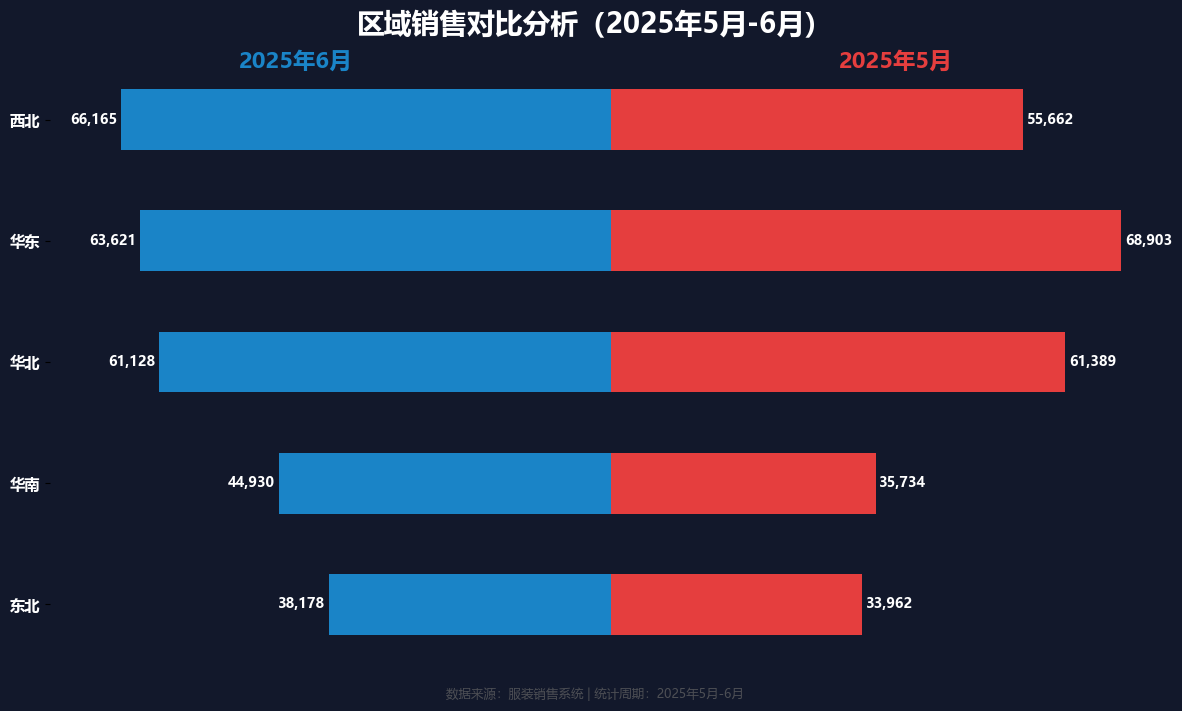

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 区域划分映射
REGION_MAP = {
    "华南": ["广东省", "广西壮族自治区", "海南省", "福建省"],
    "华北": ["北京市", "天津市", "河北省", "山西省", "内蒙古自治区"],
    "东北": ["辽宁省", "吉林省", "黑龙江省"],
    "西北": ["陕西省", "甘肃省", "青海省", "宁夏回族自治区", "新疆维吾尔自治区"],
    "华东": ["上海市", "江苏省", "浙江省", "安徽省", "山东省", "江西省"]
}

def get_region(province: str) -> str:
    """根据省份确定所属区域"""
    for region, provinces in REGION_MAP.items():
        if province in provinces:
            return region
    return "其他"

# 读取生成的数据集
try:
    # 严格读取CSV文件
    orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns = ['下单时间', '省份', '商品金额']
    for col in required_columns:
        if col not in orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")
    
    # 转换日期列
    orders['下单时间'] = pd.to_datetime(orders['下单时间'], errors='coerce')
    
    # 过滤无效日期
    orders = orders[orders['下单时间'].notnull()]
    
    # 添加区域列
    orders['区域'] = orders['省份'].apply(get_region)
    
    # 过滤掉"其他"区域
    orders = orders[orders['区域'] != "其他"]
    
    # 提取年份和月份
    orders['年份'] = orders['下单时间'].dt.year
    orders['月份'] = orders['下单时间'].dt.month
    
    # 确保只有2025年5月和6月的数据
    orders = orders[(orders['年份'] == 2025) & (orders['月份'].isin([5, 6]))]
    
    if orders.empty:
        raise ValueError("没有2025年5月或6月的订单数据")
    
    # 创建月份标识列（2025年5月/2025年6月）
    orders['月份标识'] = orders.apply(
        lambda x: f"2025年{x['月份']}月", 
        axis=1
    )
    
    # 按区域和月份标识汇总销售数据
    region_sales = orders.groupby(['区域', '月份标识'])['商品金额'].sum().reset_index()
    
    # 转换为宽格式
    pivot_data = region_sales.pivot(index='区域', columns='月份标识', values='商品金额').reset_index()
    
    # 确保两个月份都有数据
    required_months = ['2025年5月', '2025年6月']
    for month in required_months:
        if month not in pivot_data.columns:
            pivot_data[month] = 0
    
    # 填充缺失值为0
    pivot_data = pivot_data.fillna(0)
    
    # 转换为数值类型
    pivot_data['2025年5月'] = pd.to_numeric(pivot_data['2025年5月'], errors='coerce').fillna(0)
    pivot_data['2025年6月'] = pd.to_numeric(pivot_data['2025年6月'], errors='coerce').fillna(0)
    
    # 按2025年6月销售排序
    pivot_data = pivot_data.sort_values(by='2025年6月', ascending=True)
    
    # 创建深色背景的图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#12182B')  # 深蓝色背景
    ax.set_facecolor('#12182B')
    
    # 设置坐标
    y = np.arange(len(pivot_data))
    
    # 获取销售数据并转换为纯Python列表
    sales_jun = pivot_data['2025年6月'].tolist()
    sales_may = pivot_data['2025年5月'].tolist()
    regions = pivot_data['区域'].tolist()
    
    # 创建6月数据（左侧，蓝色）
    bars_jun = ax.barh(
        y, 
        [-x for x in sales_jun],  # 使用列表推导式创建负值列表
        color='#1a84c7',  # 蓝色
        edgecolor='none',
        height=0.5
    )
    
    # 创建5月数据（右侧，红色）
    bars_may = ax.barh(
        y, 
        sales_may, 
        color='#e53e3e',  # 红色
        edgecolor='none',
        height=0.5
    )
    
    # 添加顶部标题
    plt.figtext(0.5, 0.97, '区域销售对比分析（2025年5月-6月）', 
               ha='center', fontsize=20, color="#ffffff", fontweight='bold')
    
    # 添加月份标签
    plt.figtext(0.25, 0.92, '2025年6月', ha='center', fontsize=16, color='#1a84c7', fontweight='bold')
    plt.figtext(0.75, 0.92, '2025年5月', ha='center', fontsize=16, color='#e53e3e', fontweight='bold')
    
    # 设置Y轴
    ax.set_yticks(y)
    ax.set_yticklabels(regions, color="#ffffff", fontsize=11, fontweight='bold')
    
    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置X轴
    max_val_jun = max(sales_jun) if sales_jun else 0
    max_val_may = max(sales_may) if sales_may else 0
    max_val = max(max_val_jun, max_val_may) * 1.1
    ax.set_xlim(-max_val, max_val)
    ax.set_xticks([])
    
    # 添加数据标签
    for i, (bar_jun, bar_may) in enumerate(zip(bars_jun, bars_may)):
        # 6月标签（左侧）
        width_jun = bar_jun.get_width()
        # 使用正值来定位标签
        ax.annotate(
            f"{int(-width_jun):,}",
            xy=(width_jun - 500, bar_jun.get_y() + bar_jun.get_height()/2),
            ha='right',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )
        
        # 5月标签（右侧）
        width_may = bar_may.get_width()
        ax.annotate(
            f"{int(width_may):,}",
            xy=(width_may + 500, bar_may.get_y() + bar_may.get_height()/2),
            ha='left',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )
    
    # 添加底部装饰
    plt.figtext(0.5, 0.02, 
               '数据来源：服装销售系统 | 统计周期：2025年5月-6月', 
               ha='center', 
               fontsize=9, 
               color='#666666',
               alpha=0.7)
    
    # 修复rect参数类型问题
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存高清图片
    plt.savefig('区域销售对比分析（2025年5月-6月）.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()
    
except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析：

- **西北区域**：
  在2025年6月，西北区域的销售量为66,165，相较于2025年5月的55,662，呈现出显著增长，表明该区域在近期内市场需求有所提升。

- **华东区域**：
  华东区域在2025年6月的销售量为63,621，而5月为68,903，显示该区域在6月份的销售量有所下降，可能需要进一步分析原因。

- **华北区域**：
  华北区域在2025年6月的销售量为61,128，5月为61,389，变化不大，表明该区域的销售表现相对稳定。

- **华南区域**：
  华南区域在2025年6月的销售量为44,930，而5月为35,734，显示出显著的增长，可能反映了该区域市场潜力的释放。

- **东北区域**：
  东北区域在2025年6月的销售量为38,178，5月为33,962，同样显示出增长趋势，尽管增长幅度相对较小。

# 结论：

从区域销售数据的对比分析来看，西北和华南区域在2025年6月表现出较强的市场增长潜力，尤其是华南区域，其销售量增长显著。华东区域虽然在5月表现强劲，但在6月出现了销售量下降，这可能与季节性因素、市场竞争或消费者偏好变化有关。华北和东北区域的销售表现相对稳定，但东北区域的增长趋势值得关注。这些数据为进一步的市场分析和策略制定提供了基础，有助于理解不同区域的市场动态和消费者需求。